# LIME — a step-by-step walkthrough (breast cancer, real data)

569 real patients, a real 30-feature RandomForest, and a real decision
boundary. We build a LIME explanation one layer at a time, on a fixed set
of axes, and then ask the harder question: how much of it should we
believe?

**What you should be able to do after this notebook**

1. State what LIME optimizes, and name each term of its objective.
2. Follow the mechanism end to end: perturb → predict → weight → fit.
3. Read a local fit off a plot — and say what its $R^2$ does and does
   *not* tell you.
4. Name two structural limitations of the method that are visible in
   these very figures.

Companion notebook: `lime_internals.ipynb` validates every formula used
here against the source code of the `lime` package, and documents how the
patient below was selected.

## Setup

In [1]:
%pip install -q lime scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
BLUE = "#315B86"        # benign
TERRACOTTA = "#C96F3F"  # malignant
DARK = "#252525"
GRAY = "#A8A8A8"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 140})

## What LIME is

Many models — like the 300-tree RandomForest used here — are black boxes:
they predict well, but you cannot read the "why" off their parameters.
LIME (*Local Interpretable Model-agnostic Explanations*, Ribeiro, Singh &
Guestrin, 2016) does not try to explain the whole model. It explains its
behavior **near one specific prediction**, by approximating it there with
a simple model — a straight line.

In one sentence: generate synthetic neighbors around the point, ask the
real model what it thinks of each one, and fit a weighted regression to
those answers, giving more weight to neighbors closer to the point.

## What we are optimizing

$$\xi(x) = \operatorname*{arg\,min}_{g \,\in\, G} \;\; \mathcal{L}(f, g, \pi_x) \, + \, \Omega(g)$$

| symbol | what it is | here |
|---|---|---|
| $f$ | the real model (black box) | the 300-tree RandomForest |
| $g$ | the local interpretable model | a Ridge regression |
| $\pi_x$ | proximity weight of neighbor $z$ to $x$ | $\pi_x(z) = \sqrt{\exp(-d(x,z)^2/\nu^2)}$ |
| $\mathcal{L}$ | how badly $g$ reproduces $f$ nearby | squared error, weighted by $\pi_x$ |
| $\Omega(g)$ | complexity penalty on $g$ | only the 8 highest-weight features enter |

Each of the next six steps puts one of these pieces on a plot.

## The model and the patient

**The model.** 300 trees, `min_samples_leaf=3`. The tree count was not
tuned by cross-validation here — it is a common manual choice (sklearn's
default is 100; more trees reduce the variance of the predicted
probabilities with diminishing returns).

**The patient.** #67 of the test set, chosen by the systematic search in
`lime_internals.ipynb`. The criteria are worth stating, because they are
what make the figures readable:

1. the model classifies her **correctly**;
2. she sits **near the decision boundary** ($|P - 0.5| < 0.15$) — otherwise
   the local fit's $P=0.5$ line is forced far away from her, and the plot
   shows two unrelated lines instead of one approximating the other;
3. her two highest-weight features are **not near-duplicates** of each
   other ($|r| < 0.6$) — otherwise the real patients collapse onto a thin
   1-D ribbon and the 2-D plot has no structure to show.

Out of 143 test patients, exactly one satisfies all three. That scarcity
is itself a finding, and `lime_internals.ipynb` shows the full ranking.

In [3]:
data = load_breast_cancer()
X_all, y_all = data.data, data.target
feature_names = list(data.feature_names)
class_names = list(data.target_names)  # ['malignant', 'benign']
feat_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE, stratify=y_all
)
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, model.predict(X_test))
test_auc = roc_auc_score(y_test, proba_test)

instance_idx = 67  # see lime_internals.ipynb for the search that picks this patient
row = X_test[instance_idx]
row_proba = proba_test[instance_idx]
predicted = class_names[int(row_proba >= 0.5)]
true_label = class_names[y_test[instance_idx]]

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
row_scaled = (row - train_mean) / train_std
kernel_width = 0.75 * np.sqrt(len(feature_names))

axis_x_name, axis_y_name = "worst perimeter", "worst texture"
ix, iy = feat_idx[axis_x_name], feat_idx[axis_y_name]
axis_corr = np.corrcoef(X_train[:, ix], X_train[:, iy])[0, 1]

print(f"patient #{instance_idx}: P(benign)={row_proba:.3f}  predicted={predicted}  true={true_label}")
print(f"model: test accuracy={test_acc:.1%}  ROC-AUC={test_auc:.3f}")
print(f"plot axes: {axis_x_name}={row[ix]:.1f}  |  {axis_y_name}={row[iy]:.1f}")
print(f"correlation between the two axes: {axis_corr:+.2f}  (low enough for a real 2-D picture)")


def boundary_slice(clf, base_row, grid_x, grid_y):
    """The REAL decision boundary of the 30-feature model, sliced along the
    plane of the 2 chosen axes — the other 28 features stay fixed at THIS
    patient's values (ceteris paribus). The slice is exact; only the
    *viewing* is 2-D."""
    GX, GY = np.meshgrid(grid_x, grid_y)
    points = np.tile(base_row, (GX.size, 1))
    points[:, ix] = GX.ravel()
    points[:, iy] = GY.ravel()
    proba = clf.predict_proba(points)[:, 1]
    return GX, GY, proba.reshape(GX.shape)


# ONE window, used by every plot below and by the combined figure: ±1.5σ
# around the patient on each axis, clipped to the real data range. Keeping
# it fixed means nothing moves between steps except what LIME adds. The
# zoom is deliberately tight — at the full data range the boundary and the
# local fit are only a couple of pixels apart and the whole point is lost;
# ±1.5σ still leaves ~370 real patients on screen for context, and is wide
# enough to contain the 2.4σ neighborhood ellipse of step 2.
WINDOW = 1.5
lo_x, hi_x = X_all[:, ix].min(), X_all[:, ix].max()
lo_y, hi_y = X_all[:, iy].min(), X_all[:, iy].max()
grid_x = np.linspace(max(lo_x, row[ix] - WINDOW * train_std[ix]), min(hi_x, row[ix] + WINDOW * train_std[ix]), 220)
grid_y = np.linspace(max(lo_y, row[iy] - WINDOW * train_std[iy]), min(hi_y, row[iy] + WINDOW * train_std[iy]), 200)
GX, GY, PROB_SLICE = boundary_slice(model, row, grid_x, grid_y)
print(f"real boundary crosses this window: {PROB_SLICE.min() < 0.5 < PROB_SLICE.max()}")

patient #67: P(benign)=0.581  predicted=benign  true=benign
model: test accuracy=95.1%  ROC-AUC=0.993
plot axes: worst perimeter=113.1  |  worst texture=19.1
correlation between the two axes: +0.35  (low enough for a real 2-D picture)
real boundary crosses this window: True


## Drawing tools

The same layers, reused by every step and by the final combined figure.

In [4]:
FIG_DIR = "figures_generated"  # regenerated on each run; the committed copies live in ../figures
os.makedirs(FIG_DIR, exist_ok=True)


def new_figure(title, figsize=(8.5, 6.6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    return fig, ax


def draw_base(ax):
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=24, color=BLUE, alpha=0.5,
               linewidth=0, label="benign (true label)")
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=24, color=TERRACOTTA, alpha=0.5,
               linewidth=0, label="malignant (true label)")
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[DARK], linewidths=1.8, linestyles="--")
    ax.plot([], [], color=DARK, linewidth=1.8, linestyle="--", label="true boundary (P=0.5)")
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=11)
    ax.set_ylabel(axis_y_name, fontsize=11)
    ax.tick_params(labelsize=9.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def draw_patient(ax, annotate=False):
    ax.scatter(row[ix], row[iy], s=200, marker="x", color=DARK, linewidths=3,
               zorder=20, label=f"patient #{instance_idx}")
    if annotate:
        ax.annotate(f"P(benign) = {row_proba:.3f}", (row[ix], row[iy]),
                    xytext=(12, 14), textcoords="offset points", fontsize=10,
                    color=DARK, fontweight="bold")


def draw_neighborhood(ax):
    ellipse = Ellipse((row[ix], row[iy]), width=2.4 * train_std[ix], height=2.4 * train_std[iy],
                      fill=False, color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85)
    ax.add_patch(ellipse)
    ax.plot([], [], color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85,
            label="local neighborhood (2.4σ)")


def draw_neighbors(ax, Z, colors=GRAY, sizes=24, alphas=0.55, label=None):
    ax.scatter(Z[:, ix], Z[:, iy], s=sizes, color=colors, alpha=alphas, linewidth=0, label=label)


def local_line(exp, base_row, grid_x, grid_y):
    """The P=0.5 line of the official local fit. `local_exp` / `intercept`
    are coefficients in STANDARDIZED space — the package fits on
    standardized data, not raw units (validated line by line in
    `lime_internals.ipynb`) — so we convert into that space, solve, and
    convert back only to draw."""
    coef_map = dict(exp.local_exp[1])
    base_scaled = (base_row - train_mean) / train_std
    others = sum(w * base_scaled[j] for j, w in coef_map.items() if j not in (ix, iy))
    grid_x_scaled = (grid_x - train_mean[ix]) / train_std[ix]
    y_scaled = (0.5 - exp.intercept[1] - others - coef_map[ix] * grid_x_scaled) / coef_map[iy]
    y_line = y_scaled * train_std[iy] + train_mean[iy]
    inside = (y_line >= grid_y.min()) & (y_line <= grid_y.max())
    return y_line, inside


def draw_line(ax, exp, grid_x, grid_y):
    coef_map = dict(exp.local_exp[1])
    if ix not in coef_map or iy not in coef_map or abs(coef_map[iy]) < 1e-9:
        return False
    y_line, inside = local_line(exp, row, grid_x, grid_y)
    if inside.any():
        ax.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=3,
                 label="local fit (Ridge, P=0.5)")
        return True
    return False


def add_legend(ax):
    ax.legend(loc="upper left", fontsize=9, frameon=True, framealpha=0.92, edgecolor="none")


def save_figure(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=200, bbox_inches="tight")

## Step 1 — the black-box model

A classifier that returns P(benign) for any patient. We never look inside
it; we only call `predict_proba()`.

**What to look for:** the dashed line is the model's real decision
boundary, and our patient (the ✕) sits right on it. It is not a smooth
diagonal — a RandomForest splits one feature at a time, so even an
average of 300 trees produces staircase-like, "elbowed" boundaries.

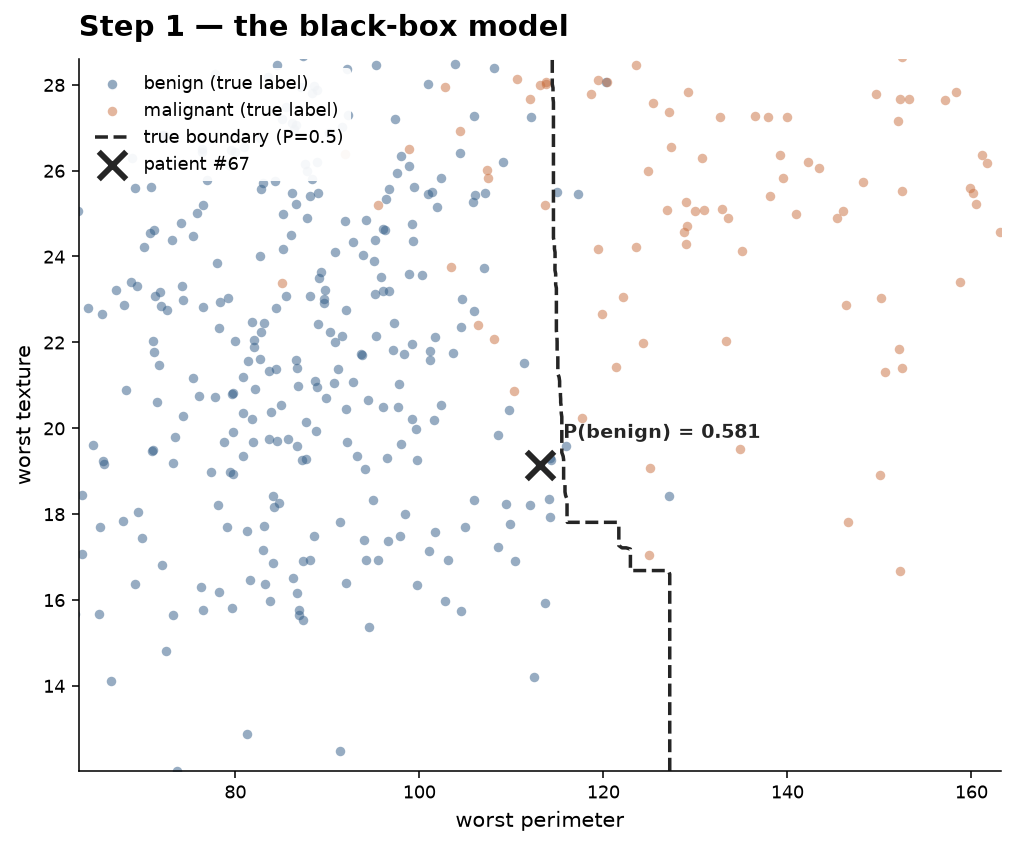

In [5]:
fig, ax = new_figure("Step 1 — the black-box model")
draw_base(ax)
draw_patient(ax, annotate=True)
add_legend(ax)
save_figure(fig, "lime_step_1")
plt.show()

## Step 2 — the local neighborhood

LIME explains behavior *near* this patient, so it needs a notion of
"near". In 30 dimensions there is no single radius: each feature has its
own scale, hence its own width (its σ in the training set).

**What to look for:** the neighborhood is an ellipse, not a circle —
wider along the axis with more natural variation. Note also how large it
is: LIME's default kernel width is generous, which matters later.

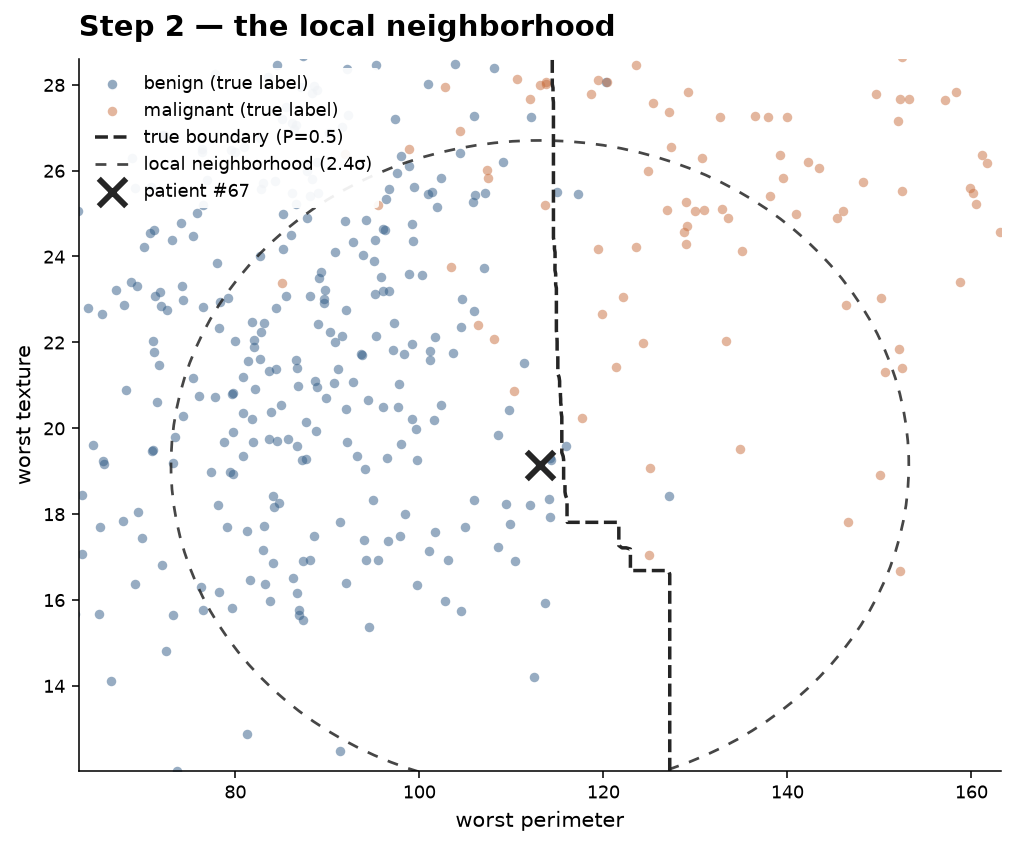

In [6]:
fig, ax = new_figure("Step 2 — the local neighborhood")
draw_base(ax)
draw_neighborhood(ax)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_2")
plt.show()

## Step 3 — perturbation: synthetic neighbors

$$z = \mu + \sigma \cdot \mathcal{N}(0,1)$$

— across all 30 features at once, each with its own training mean and σ.
We plot the projection onto our 2 axes; the real run uses 5,000 neighbors.

**What to look for:** the grey dots sit *between* and *around* the real
patients rather than following their band — LIME is probing the model in
places the data does not densely occupy.

**Two caveats worth saying out loud.** First, we are zoomed in: the count
printed below shows how few of the neighbors actually fall inside this
frame. LIME's default neighborhood is far larger than what you see here,
which is exactly why its $R^2$ is a statement about a big region, not
about the immediate vicinity of the ✕. Second, LIME draws **each feature
independently**, destroying the correlations present in real data, so
some synthetic "patients" are physically impossible combinations. Our two
axes correlate at only $r = 0.35$, so the distortion here is mild — but
for a strongly correlated pair (`worst area` and `worst perimeter`
correlate at $0.98$) the cloud would be almost entirely off-manifold.
This is a standing criticism of perturbation-based explanations, and it
is better seen than hidden.

275 of the 500 synthetic neighbors fall inside this zoomed window; the other 225 are further out.
(the real run uses 5,000 neighbors — these 500 are only for the picture)


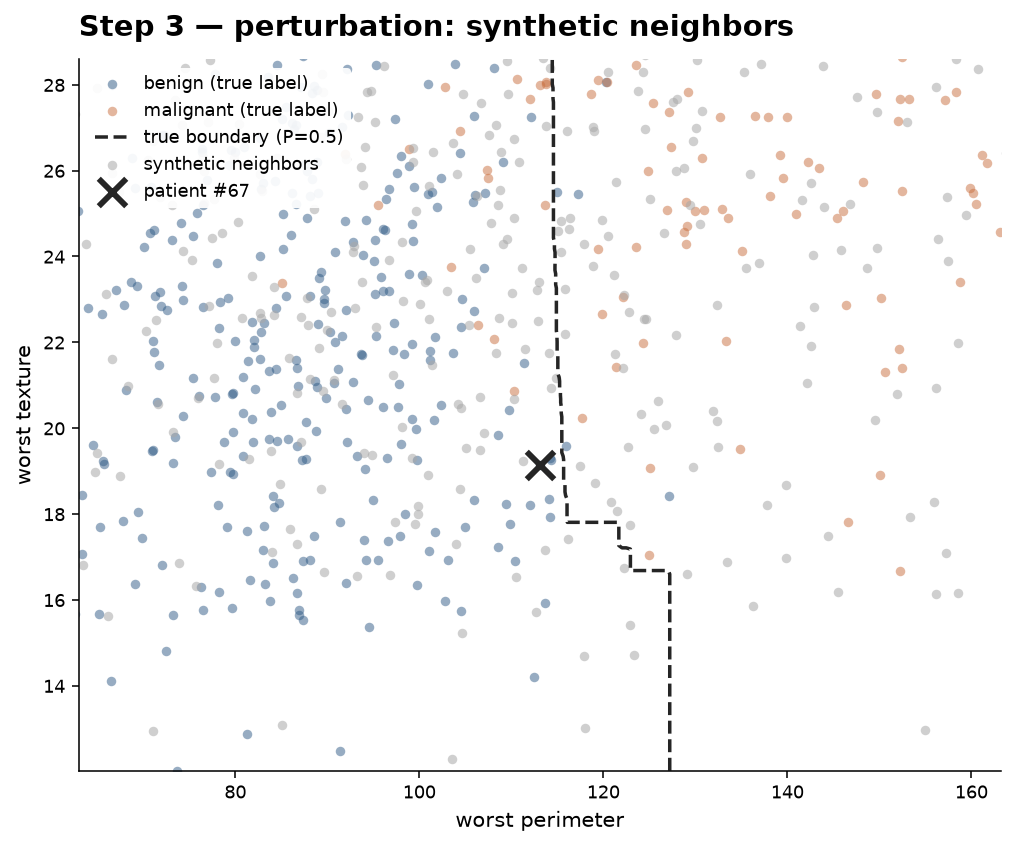

In [7]:
rng_vis = np.random.RandomState(RANDOM_STATE)
N_VIS = 500
Z_vis = train_mean + train_std * rng_vis.normal(0, 1, size=(N_VIS, len(feature_names)))

in_window = ((Z_vis[:, ix] >= grid_x.min()) & (Z_vis[:, ix] <= grid_x.max()) &
             (Z_vis[:, iy] >= grid_y.min()) & (Z_vis[:, iy] <= grid_y.max()))
print(f"{in_window.sum()} of the {N_VIS} synthetic neighbors fall inside this zoomed window; "
      f"the other {N_VIS - in_window.sum()} are further out.")
print("(the real run uses 5,000 neighbors — these 500 are only for the picture)")

fig, ax = new_figure("Step 3 — perturbation: synthetic neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=GRAY, label="synthetic neighbors")
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_3")
plt.show()

## Step 4 — what the model says about each neighbor

The only moment the real model is queried: `predict_proba` on every
synthetic neighbor. To the model, each one is just another row of 30
numbers.

**What to look for:** the colours split along the model's own boundary,
not along the true labels. This is the data LIME will actually fit — we
are explaining $f$, not the diagnosis.

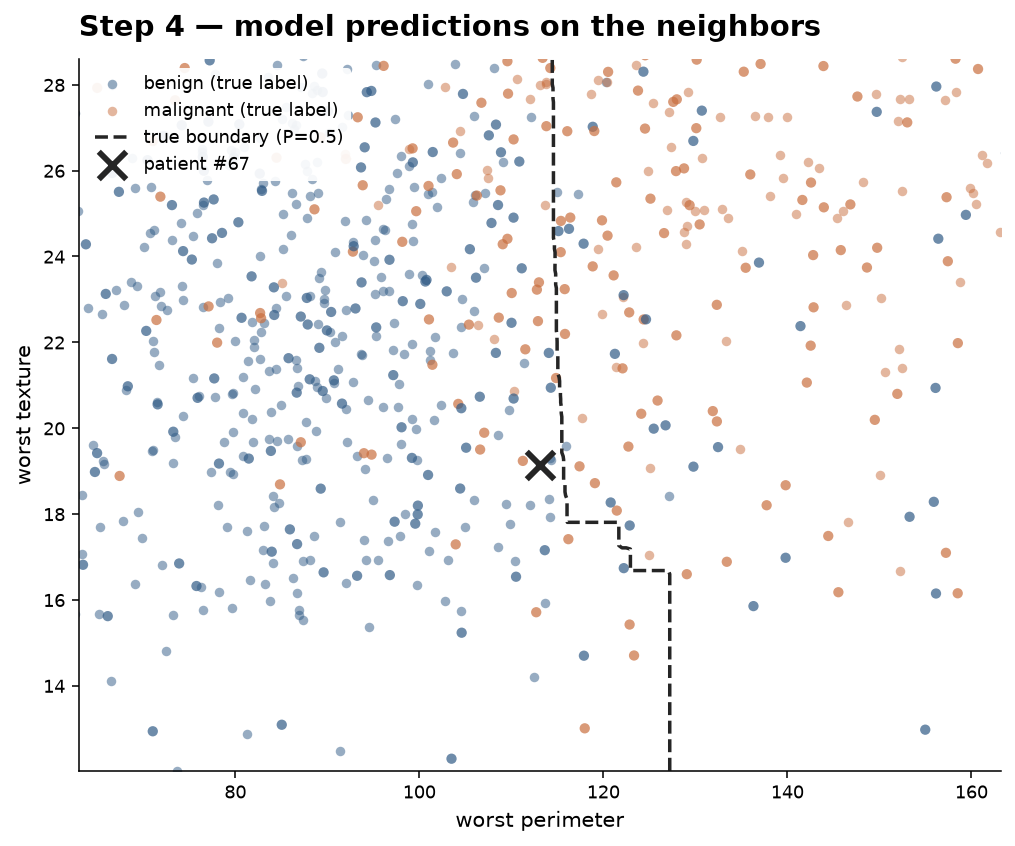

In [8]:
Z_vis_proba = model.predict_proba(Z_vis)[:, 1]
neighbor_colors = np.where(Z_vis_proba >= 0.5, BLUE, TERRACOTTA)

fig, ax = new_figure("Step 4 — model predictions on the neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=28, alphas=0.7)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_4")
plt.show()

## Step 5 — proximity weighting

$$\pi_x(z) = \sqrt{\exp\!\left(-\dfrac{d(x,z)^2}{\nu^2}\right)}, \qquad \nu = 0.75\sqrt{30}$$

**What to look for:** dot size and opacity now encode $\pi_x$ — this is
the first step where the neighbors stop being equals. One subtlety worth
saying aloud: the distance is computed over all **30 standardized**
features, not the 2 on screen. So a dot that looks far from the ✕ here
can still be heavy, if it resembles the patient on the other 28 features.
The sizes are faithful to the real weights, not to the on-screen distance.

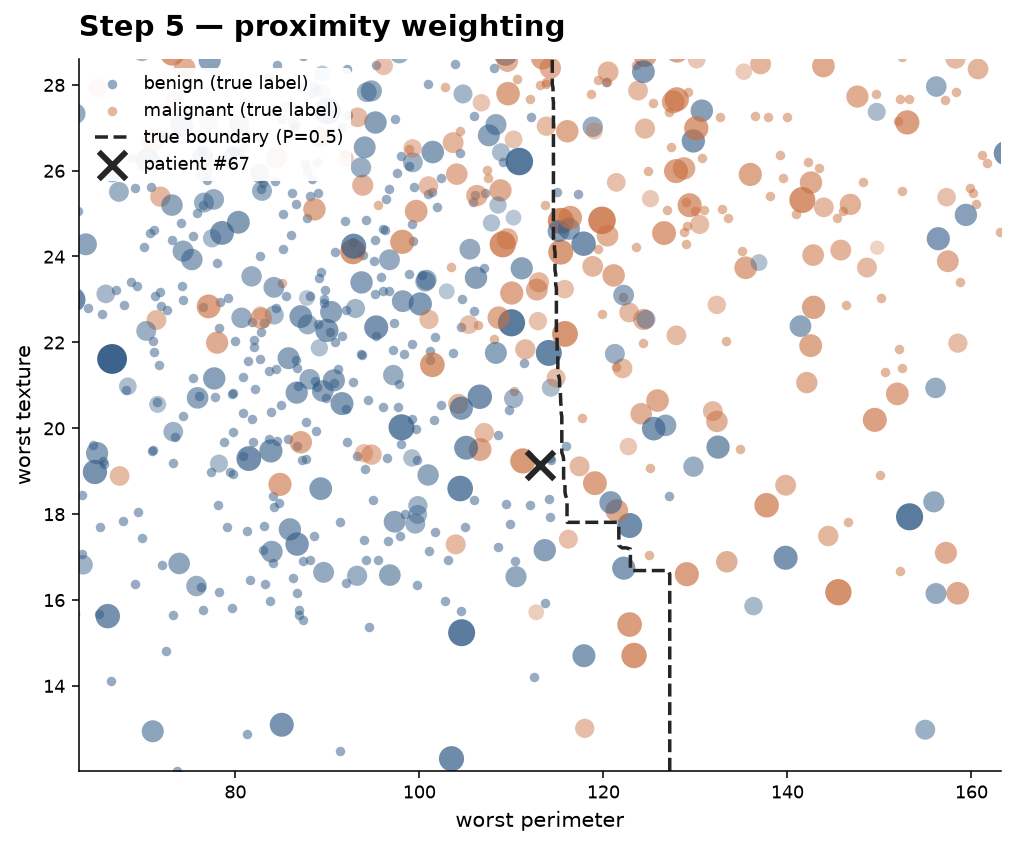

In [9]:
Z_vis_scaled = (Z_vis - train_mean) / train_std
dist_vis = np.linalg.norm(Z_vis_scaled - row_scaled, axis=1)
weight_vis = np.sqrt(np.exp(-(dist_vis ** 2) / (kernel_width ** 2)))
neighbor_sizes = 15 + 220 * (weight_vis / weight_vis.max())
neighbor_alphas = np.clip(0.15 + 0.8 * (weight_vis / weight_vis.max()), 0, 1)

fig, ax = new_figure("Step 5 — proximity weighting")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_5")
plt.show()

## Step 6 — the local fit

The solid line is the explanation. It is a **linear** model: a Ridge
regression (`alpha=1`, the package default) fitted on the 8 highest-weight
features, with each neighbor weighted by its $\pi_x$. What is drawn is
that weighted sum solved for $P=0.5$ and projected onto our 2 axes.

**What to look for:** the solid line meets the dashed one right at the ✕
and departs from it as you move away. Notice that their *slopes* differ:
the real boundary is a near-vertical staircase, because the forest splits
on one feature at a time and is deciding this case mostly on
`worst perimeter` alone; the linear fit cannot reproduce a staircase, so
it settles for a tilted line that agrees with it at the patient and
spreads the credit across both axes. That is the whole idea of LIME in
one picture — and, in the same picture, the price of insisting on a
straight-line story.

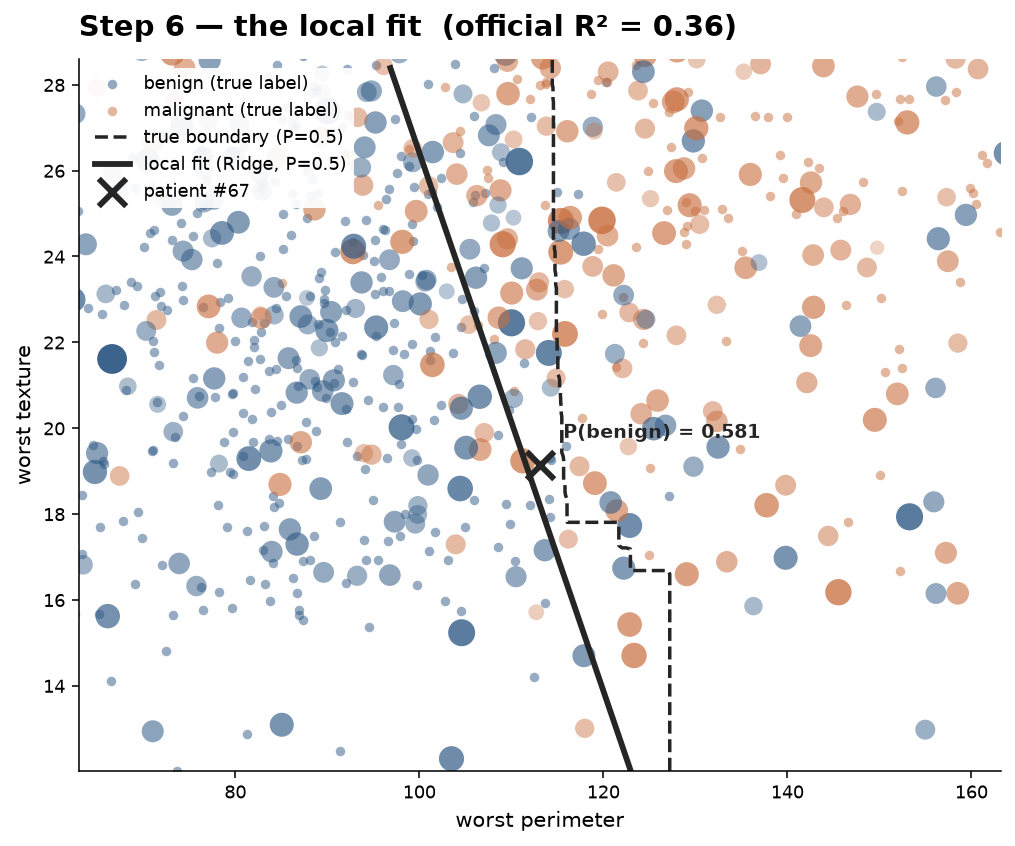

R² (local fidelity, official): 0.357
distance from the patient to the true boundary: 0.08σ
distance from the patient to the local-fit line: 0.04σ

highest-weight feature: worst perimeter (-0.0709)
all eight weights (negative = pushes toward malignant):
  worst perimeter            -0.0709
  worst concave points       -0.0457
  worst texture              -0.0213
  area error                 -0.0184
  mean texture               -0.0153
  mean perimeter             -0.0140
  mean radius                -0.0134
  radius error               -0.0089


In [10]:
explainer = LimeTabularExplainer(
    X_train, feature_names=feature_names, class_names=class_names,
    discretize_continuous=False, random_state=RANDOM_STATE,
)
exp = explainer.explain_instance(
    row, model.predict_proba, num_features=8, num_samples=5000, labels=(1,)
)
r2 = exp.score
weights_map = {feature_names[f]: w for f, w in exp.local_exp[1]}
top_feat = max(weights_map, key=lambda f: abs(weights_map[f]))
i_top = feat_idx[top_feat]

fig, ax = new_figure(f"Step 6 — the local fit  (official R² = {r2:.2f})")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas)
line_visible = draw_line(ax, exp, grid_x, grid_y)
draw_patient(ax, annotate=True)
add_legend(ax)
save_figure(fig, "lime_step_6")
plt.show()

# how close are the two lines to the patient, in standard deviations?
grad_2d = np.hypot(dict(exp.local_exp[1]).get(ix, 0.0), dict(exp.local_exp[1]).get(iy, 0.0))
dist_to_line = abs(exp.local_pred[0] - 0.5) / grad_2d
side = PROB_SLICE >= 0.5
edge = np.zeros_like(side)
edge[:, :-1] |= side[:, :-1] != side[:, 1:]
edge[:-1, :] |= side[:-1, :] != side[1:, :]
dist_to_boundary = np.min(np.hypot((GX[edge] - row[ix]) / train_std[ix],
                                    (GY[edge] - row[iy]) / train_std[iy]))

print(f"R² (local fidelity, official): {r2:.3f}")
print(f"distance from the patient to the true boundary: {dist_to_boundary:.2f}σ")
print(f"distance from the patient to the local-fit line: {dist_to_line:.2f}σ")
print(f"\nhighest-weight feature: {top_feat} ({weights_map[top_feat]:+.4f})")
print("all eight weights (negative = pushes toward malignant):")
for f, w in sorted(exp.local_exp[1], key=lambda t: abs(t[1]), reverse=True):
    print(f"  {feature_names[f]:<26} {w:+.4f}")

## How much of this should we believe?

Two numbers are easy to confuse, so let us separate them.

The **prediction** always comes from the RandomForest. The straight line
never overrides it; it only summarizes it. The **fidelity** ($R^2$) says
how well that summary tracks the real model across the weighted
neighborhood.

In [11]:
print(f"P(benign) from the real model, at the patient:  {row_proba:.4f}")
print(f"P(benign) from the linear fit, at the patient:  {exp.local_pred[0]:.4f}")
print(f"gap at the patient:                             {abs(row_proba - exp.local_pred[0]):.4f}")
print(f"R² over the weighted neighborhood:              {r2:.4f}")

P(benign) from the real model, at the patient:  0.5812
P(benign) from the linear fit, at the patient:  0.4968
gap at the patient:                             0.0843
R² over the weighted neighborhood:              0.3572


### A trap: high $R^2$ does not mean a better explanation

It is tempting to read $R^2$ as a quality score and to prefer patients
with high values. That reading is wrong, and it is measurable. Across all
143 test patients, $R^2$ tracks how *confident* the prediction is
(Spearman $\rho = +0.57$, $p \approx 8\times10^{-14}$ — computed in
`lime_internals.ipynb`):

| group | mean $R^2$ |
|---|---|
| borderline patients ($\lvert P-0.5\rvert < 0.15$) | 0.45 |
| confident patients ($\lvert P-0.5\rvert > 0.3$) | 0.60 |

The reason is mechanical. Far from the boundary the model is saturated —
its output barely moves — and a straight line reproduces "almost
constant" very easily. A high $R^2$ there largely certifies that *nothing
is happening*, not that the explanation is more insightful.

Our patient sits on the boundary, in the regime where an explanation is
most worth having and where a linear fit has the hardest job. Her
moderate $R^2$ is the honest price of that position, not a defect of the
figure. Reported alone, without the geometry, the number would flatter a
vacuous explanation and penalize a useful one.

### A second trap: the line does not know when to stop

$g$ is linear, so it extrapolates forever, while $f$ saturates. Push far
enough along the strongest feature and the "probability" leaves $[0,1]$
entirely — a reminder that the explanation is licensed only near the ✕.

In [12]:
coef_map = dict(exp.local_exp[1])
print(f"moving only '{top_feat}', holding the other 29 features fixed:")
for delta in [0, 1, 2, 4, 8]:
    probe = row.copy()
    probe[i_top] = row[i_top] + delta * train_std[i_top]
    real = model.predict_proba(probe.reshape(1, -1))[0, 1]
    zs = (probe - train_mean) / train_std
    line_pred = exp.intercept[1] + sum(w * zs[j] for j, w in coef_map.items())
    warn = "  ← outside [0,1]: impossible" if not (0 <= line_pred <= 1) else ""
    print(f"  +{delta}σ: real model={real:.3f}   linear fit={line_pred:.3f}{warn}")

moving only 'worst perimeter', holding the other 29 features fixed:
  +0σ: real model=0.581   linear fit=0.497
  +1σ: real model=0.478   linear fit=0.426
  +2σ: real model=0.478   linear fit=0.355
  +4σ: real model=0.478   linear fit=0.213
  +8σ: real model=0.478   linear fit=-0.070  ← outside [0,1]: impossible


### What the book says

From Molnar,
[*Interpretable Machine Learning*, LIME chapter](https://christophm.github.io/interpretable-ml-book/lime.html):

> "The learned model should be a good approximation of the machine
> learning model predictions locally, but it does not have to be a good
> global approximation. This kind of accuracy is also called **local
> fidelity**."

> "The fidelity measure (...) gives us a good idea of how reliable the
> interpretable model is in explaining the black box predictions in the
> neighborhood of the data instance of interest."

Molnar also flags two limitations that this notebook has now shown
concretely: the **choice of neighborhood**, which has no principled
answer and which we simply left at the package default (step 2), and the
**instability** of explanations across runs, demonstrated empirically in
`lime_internals.ipynb`.

## The six steps, side by side

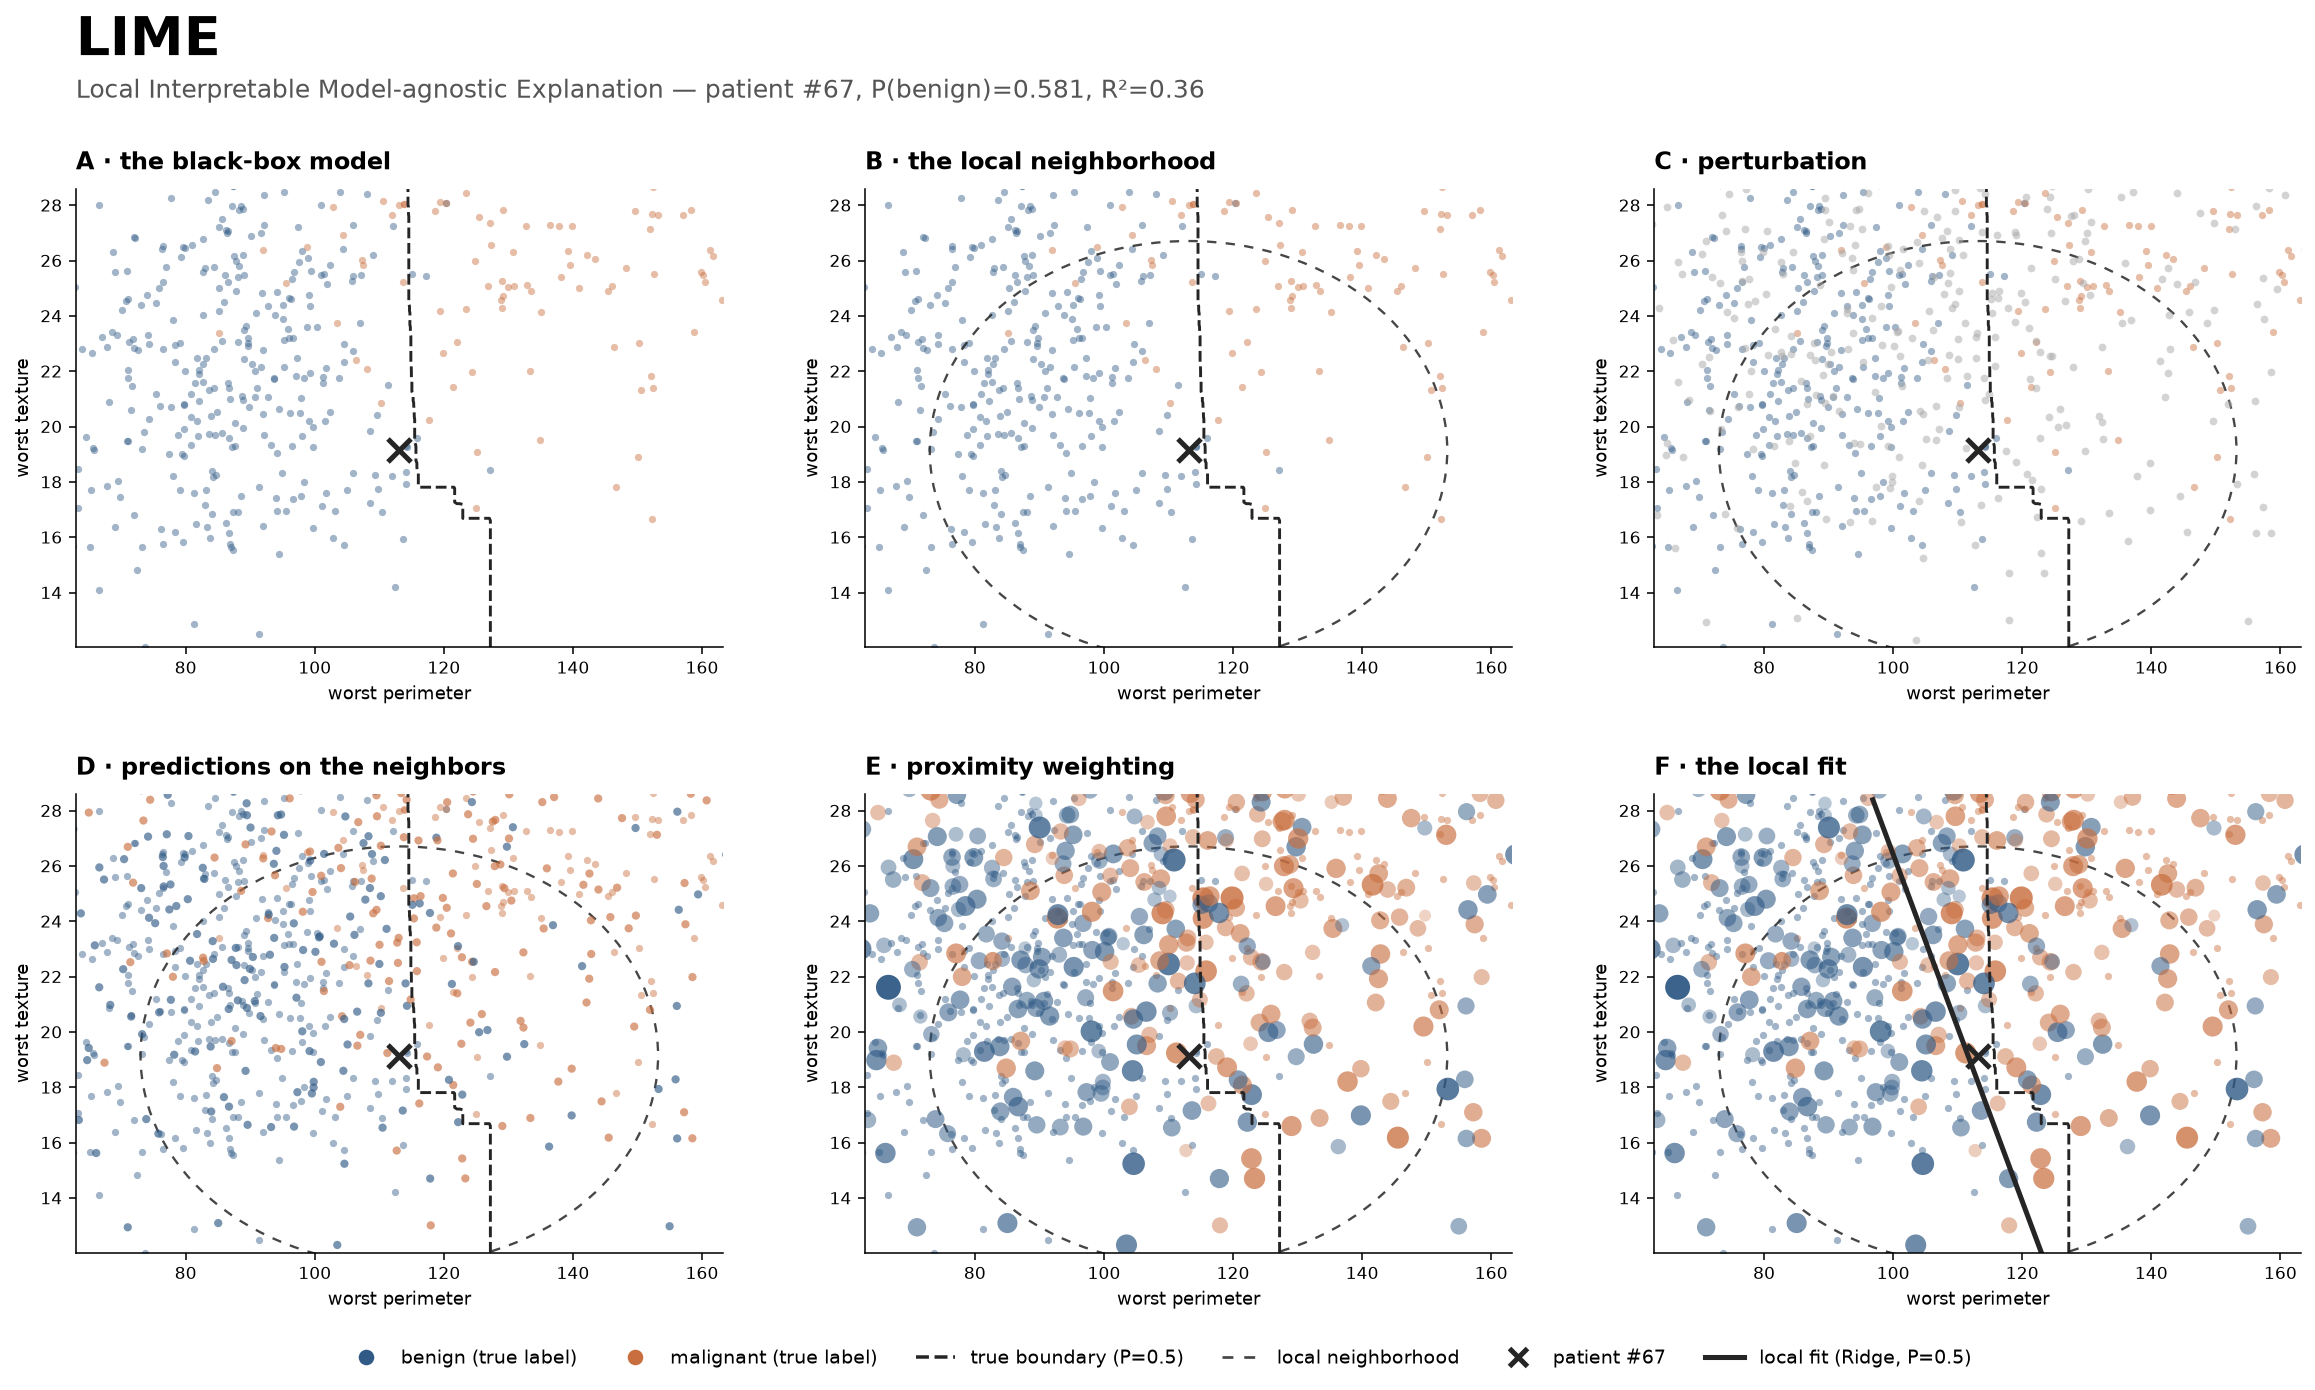

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.subplots_adjust(left=0.045, right=0.98, top=0.86, bottom=0.10, wspace=0.22, hspace=0.32)

panel_titles = [
    "A · the black-box model", "B · the local neighborhood", "C · perturbation",
    "D · predictions on the neighbors", "E · proximity weighting", "F · the local fit",
]
axA, axB, axC, axD, axE, axF = axes.ravel()

for ax, title in zip(axes.ravel(), panel_titles):
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=10)
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=9.5)
    ax.set_ylabel(axis_y_name, fontsize=9.5)
    ax.tick_params(labelsize=8.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=14, color=BLUE, alpha=0.45, linewidth=0)
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=14, color=TERRACOTTA, alpha=0.45, linewidth=0)
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[DARK], linewidths=1.5, linestyles="--")

# an Ellipse (a Patch) belongs to one axes at a time — each panel needs its own
for ax in (axB, axC, axD, axE, axF):
    ax.add_patch(Ellipse(
        (row[ix], row[iy]), width=2.4 * train_std[ix], height=2.4 * train_std[iy],
        fill=False, color=DARK, linewidth=1.2, linestyle=(0, (4, 4)), alpha=0.85))

axC.scatter(Z_vis[:, ix], Z_vis[:, iy], s=16, color=GRAY, alpha=0.5, linewidth=0)
axD.scatter(Z_vis[:, ix], Z_vis[:, iy], s=18, color=neighbor_colors, alpha=0.65, linewidth=0)
for ax in (axE, axF):
    ax.scatter(Z_vis[:, ix], Z_vis[:, iy], s=neighbor_sizes * 0.7, color=neighbor_colors,
               alpha=neighbor_alphas, linewidth=0)

if line_visible:
    y_line, inside = local_line(exp, row, grid_x, grid_y)
    axF.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=2.6)

for ax in (axA, axB, axC, axD, axE, axF):
    ax.scatter(row[ix], row[iy], s=140, marker="x", color=DARK, linewidths=2.6, zorder=20)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=BLUE, markersize=7, label="benign (true label)"),
    plt.Line2D([], [], marker="o", linestyle="", color=TERRACOTTA, markersize=7, label="malignant (true label)"),
    plt.Line2D([], [], color=DARK, linewidth=1.8, linestyle="--", label="true boundary (P=0.5)"),
    plt.Line2D([], [], color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85, label="local neighborhood"),
    plt.Line2D([], [], marker="x", linestyle="", color=DARK, markersize=9, markeredgewidth=2.6,
               label=f"patient #{instance_idx}"),
    plt.Line2D([], [], color=DARK, linewidth=2.6, label="local fit (Ridge, P=0.5)"),
]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.005))

fig.suptitle("LIME", fontsize=28, fontweight="bold", x=0.045, ha="left", y=0.985)
fig.text(0.045, 0.925,
         f"Local Interpretable Model-agnostic Explanation — patient #{instance_idx}, "
         f"P(benign)={row_proba:.3f}, R²={r2:.2f}",
         fontsize=13, color="#555555", ha="left")

save_figure(fig, "lime_walkthrough_combined")
fig.savefig(os.path.join(FIG_DIR, "lime_walkthrough_combined.pdf"), bbox_inches="tight")
plt.show()

## Closing

The headline accuracy of this model is 95.1%, but that number is carried
almost entirely by the easy cases: among confident predictions it is
99.2%, while among the handful of borderline patients it drops to 66.7%.
Our patient is one of the borderline ones — precisely where a clinician
would want to know *why*.

What LIME gave us there is a straight line that hugs the model's real
boundary near her, a ranked list of which measurements pushed the verdict
and by how much, and a fidelity score admitting how far that story can be
stretched. What it did not give us is certainty — and the $R^2$ analysis
above shows that the cases with the most reassuring fidelity scores are
often the ones where the least is happening.

LIME's value is not that it is never wrong. It is that it tells you, case
by case, how much to trust it.

In [14]:
confident = np.abs(proba_test - 0.5) >= 0.3
borderline = np.abs(proba_test - 0.5) < 0.15
print(f"confident cases (|P-0.5| ≥ 0.3):  {confident.sum():3d} of {len(proba_test)} "
      f"({confident.sum()/len(proba_test):.0%}) — accuracy "
      f"{accuracy_score(y_test[confident], (proba_test[confident] >= 0.5).astype(int)):.1%}")
print(f"borderline cases (|P-0.5| < 0.15): {borderline.sum():3d} of {len(proba_test)} "
      f"({borderline.sum()/len(proba_test):.0%}) — accuracy "
      f"{accuracy_score(y_test[borderline], (proba_test[borderline] >= 0.5).astype(int)):.1%}")
print(f"\nour patient #{instance_idx} is one of the borderline ones "
      f"(P={row_proba:.3f}), and the model got her right.")

confident cases (|P-0.5| ≥ 0.3):  127 of 143 (89%) — accuracy 99.2%
borderline cases (|P-0.5| < 0.15):   6 of 143 (4%) — accuracy 66.7%

our patient #67 is one of the borderline ones (P=0.581), and the model got her right.
